# Using the Sust Global python client API

In [135]:
import os
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

from sust.api import ClimateExplorerClient

In [136]:
def display_fwd_timeseries_data(df, asset_index, risk_label):

    START_YEAR = 2022
    END_YEAR = 2100
    
    colors = {
    'background': '#FFFFFF',
    'text': '#AAAAAA'
    }
    
    trace_collection = []

    risk_colnames = [str(i) for i in list(range(START_YEAR, END_YEAR+1))]
    df_selected = df[df['portfolio_index']==asset_index]
    #df_selected = df[asset_index:asset_index+1]
    df_filtered = df_selected[risk_colnames].copy()

    year_labels = [x for x in df_filtered.columns.values]
    year_val = pd.to_numeric(year_labels)

    risk_val = df_filtered.values[0]
    trace_color = {'asset':'rgb(255, 0, 0)'}

    trace = go.Scatter(
        name=risk_label,
        x=year_val,
        y=risk_val,
        mode='lines',
        line=dict(width=3.0, color=trace_color['asset']))

    data = [trace]

    
    layout = go.Layout(
        title='Normalized Multi-Hazard Predictive Risk Exposure : ',
        yaxis=dict(title=risk_label,
                   showline=True,
                   showgrid=False,
                   showticklabels=True,
                   linecolor='rgb(82, 82, 82)',
                   linewidth=2,
                   ticks='outside',
                   range=[0,0.5],
                   tickfont=dict(
                         family='Arial',
                         size=12,
                         color='rgb(82, 82, 82)')
                   ),
        xaxis=dict(title='Year of Assessment',
                   showline=True,
                   showgrid=False,
                   showticklabels=True,
                   linecolor='rgb(82, 82, 82)',
                   linewidth=2,
                   ticks='outside',
                   tickfont=dict(
                         family='Arial',
                         size=12,
                         color='rgb(82, 82, 82)'),
                   rangeselector=dict(
                       buttons=list([
                           dict(count=1,
                                label='1y',
                                step='year',
                                stepmode='backward'),
                           dict(count=3,
                                label='3y',
                                step='year',
                                stepmode='backward'),
                           dict(count=6,
                                label='10y',
                                step='year',
                                stepmode='backward'),
                           dict(step='all')
                       ])
                   ),
                   rangeslider=dict(
                       visible=True
                   ),
                   type='date'),
        showlegend=True,
        legend=dict(x=0, y=1.0),
        transition_duration=50,
        plot_bgcolor=colors['background'],
        paper_bgcolor=colors['background'])

    fig = go.Figure(data=data, layout=layout)
    return fig

In [137]:
def estimated_heatmap(df):

    START_YEAR = 2022
    END_YEAR = 2072
    LOW_BP = 0.05
    HIGH_BP = 0.075
    HEATMAP_MAX_MARKER_SIZE = 16
    MAP_ZOOM_LEVEL = 2
    margin_params = {"r": 0, "l": 0, "b": 0}
    legend_params = dict(x=1, y=1.02, orientation="h", yanchor="bottom", xanchor="right")
    
    risk_colnames = [str(i) for i in list(range(START_YEAR, END_YEAR+1))]
    df_selected = df[risk_colnames]
    df_risk = pd.DataFrame({'A': []})
    df_risk['max_risk'] = df_selected.max(axis=1)
    df_risk['loss_marker'] = df_risk['max_risk']*(HEATMAP_MAX_MARKER_SIZE - 1)/0.1
    df_risk['loss_marker'] = df_risk['loss_marker'].astype(int) + 1
    df_risk['loss_marker'] = df_risk['loss_marker'].abs()
    df_risk['lat'] = df['lat'].values
    df_risk['lng'] = df['lng'].values
    df_risk['entity_name'] = df['entity_name'].values
    df_risk['visitation_count'] = df['visitation_count'].values
    
    for index, row in df_risk.iterrows():
        val = row['max_risk']

        if val <= LOW_BP:
            df_risk.loc[index, 'risk_class'] = 'LOW'
        elif val > LOW_BP and val <= HIGH_BP:
            df_risk.loc[index, 'risk_class'] = 'MEDIUM'
        else:
            df_risk.loc[index, 'risk_class'] = 'HIGH'
    df_risk.drop(['A'], axis=1, inplace=True)
    
    # map_fig = px.scatter_mapbox(df_risk, lon="lng", lat="lat", hover_name="Address", color="risk_class", color_discrete_sequence=['#00FF00', '#FFFF00', '#FF0000'], size_max=1, hover_data=[df_risk.index, "max_risk", "risk_class"], zoom=2, height=400) #size='Price', size_max=6,
    map_fig = px.scatter_mapbox(df_risk, lon="lng", lat="lat", hover_name="entity_name", color="risk_class", color_discrete_sequence=['#008CFF', '#0000FF', '#00DFFF', '#FF00FF', '#00FFFF', '#8C00FF', '#8C8C8C', '#8C008C', '#008C8C'], 
                                color_discrete_map={'LOW': '#00FF00', 'MEDIUM': '#FFFF00', 'HIGH': '#FF0000'}, size='loss_marker', size_max=HEATMAP_MAX_MARKER_SIZE, hover_data=["max_risk", "risk_class"], zoom=MAP_ZOOM_LEVEL, height=1000)  # size_max=1 size='Price', size_max=6,

    map_fig.update_layout(clickmode='event+select', mapbox_style="white-bg", margin=margin_params, legend=legend_params,
        mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "United States Geological Survey",
            "source": [
                "https://basemap.nationalmap.gov/arcgis/rest/services/USGSImageryOnly/MapServer/tile/{z}/{y}/{x}"
            ]
        }
      ])

    return map_fig, df_risk

# Use your API to find your portfolios

In [138]:
# Your API key must be provided, and a project may optionall be selected.
# Use the environment variables already wired up, or overwrite the
# following lines with your own values manually.
API_KEY = os.environ.get('SUST_API_KEY')
PROJECT = os.environ.get('SUST_PROJECT', 'sust-ptg')

cl = ClimateExplorerClient(API_KEY, project=PROJECT)

display([x for x in dir(cl) if not x.startswith('_')])

['create_portfolio', 'portfolio', 'portfolios']

# What is the status on the US National Parks portfolio ?

In [139]:
PORTFOLIO = 'USNP_with_visits'

pf = cl.portfolio(PORTFOLIO)
print("Status : ",pf['status'])

Status :  Risk data available


# Get indicators associated with this portfolio

In [140]:
# Fetch the physical risk exposure dataset metadata
ds = pf.physical_risk_exposure()
# Display the physical risk indicators available within the dataset
display(pd.DataFrame(ds.indicators.to_dicts()).sort_values('hazard').reset_index(drop=True))
    

,hazard,indicator,unit,value_min,value_max,value_norm,spatial_resolution
0,cyclone,obs_freq,frequency,0.0,2.0,2.00,1000.0
1,cyclone,prob,probability,0.0,1.0,0.50,50000.0
2,flood_potential,obs_score,score,0.0,1.0,1.00,1000.0
3,flood_potential,inland_flood_prob,probability,0.0,1.0,1.00,4000.0
4,fundamental,temp,degree_celsius,-5.0,45.0,45.00,100000.0
5,fundamental,precip,millimeter,0.0,5000.0,5000.00,100000.0
6,fundamental,extreme_precip,day,0.0,365.0,365.00,100000.0
7,heatwave,freq,day,0.0,365.0,200.00,100000.0
8,sea_level_rise,change,meter,-0.2,2.0,0.75,100000.0
9,water_stress,spei_norm,score,-3.0,3.0,3.00,100000.0


# Where are the parks located?

In [141]:
af = pd.DataFrame(pf.assets().to_dicts())
display(af[:5])

,portfolio_name,portfolio_index,entity_id,entity_name,lat,lng,labels
0,USNP_with_visits,105,,Lowell National Historical Park,42.645480,-71.312228,"{'rank': '257', 'visitation_count': '49721'}"
1,USNP_with_visits,104,,Steamtown National Historic Site,41.407972,-75.671569,"{'rank': '252', 'visitation_count': '54433'}"
2,USNP_with_visits,103,,Bluestone National Scenic River,37.560854,-80.995485,"{'rank': '292', 'visitation_count': '26710'}"
3,USNP_with_visits,102,,Timucuan Ecological and Historic Preserve,30.475748,-81.452105,"{'rank': '78', 'visitation_count': '935419'}"
4,USNP_with_visits,101,,Acadia National Park,44.337936,-68.245465,"{'rank': '16', 'visitation_count': '4069098'}"


,entity_name,lng,lat,label:rank,label:visitation_count
0,Abraham Lincoln Birthplace National Historical...,-85.642493,37.612073,8,5792331
1,White House,-77.036556,38.896948,332,14205
2,Manzanar National Historic Site,-118.153032,36.726999,208,117113
3,Canaveral National Seashore,-80.747776,28.778219,37,2218059
4,Colorado National Monument,-108.689320,39.054719,118,499841


# Get risk exposure times series associated with a portfolio

In [143]:
ts = ds.timeseries(
    ds.scenarios.get('ssp585'),
    ds.indicators.get('wildfire', 'fire_kbdi_susceptibility'),
    ds.measures.get('mid'),
)

df = pd.DataFrame(ts.to_dicts())
display(df[:5])

,portfolio_name,portfolio_index,entity_id,entity_name,hazard,indicator,scenario,measure,1980,1981,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,USNP_with_visits,0,,Abraham Lincoln Birthplace National Historical...,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.029292,0.029479,...,0.049177,0.049186,0.050111,0.050217,0.050745,0.050670,0.051763,0.051900,0.052647,0.053732
1,USNP_with_visits,1,,White House,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.007166,0.007163,...,0.009527,0.009563,0.009673,0.009733,0.009786,0.009801,0.009864,0.009910,0.009965,0.009995
2,USNP_with_visits,2,,Manzanar National Historic Site,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.044105,0.044298,...,0.066518,0.066293,0.066871,0.066652,0.066813,0.065831,0.066428,0.065840,0.065789,0.066021
3,USNP_with_visits,3,,Canaveral National Seashore,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.017775,0.017775,...,0.017775,0.017775,0.017775,0.017775,0.017775,0.017775,0.017775,0.017775,0.017775,0.017775
4,USNP_with_visits,4,,Colorado National Monument,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.030775,0.030378,...,0.077599,0.073564,0.078207,0.077671,0.079582,0.079734,0.084835,0.084081,0.086616,0.088924


# What is the temporal risk profile associated with a specific property in the portfolio?

In [144]:
asset_index = 98

display(df[df['portfolio_index']==asset_index])

,portfolio_name,portfolio_index,entity_id,entity_name,hazard,indicator,scenario,measure,1980,1981,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
98,USNP_with_visits,98,,Olympic National Park,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.022219,0.022384,...,0.419883,0.443129,0.469721,0.473863,0.466689,0.482887,0.485666,0.488944,0.491218,0.476197


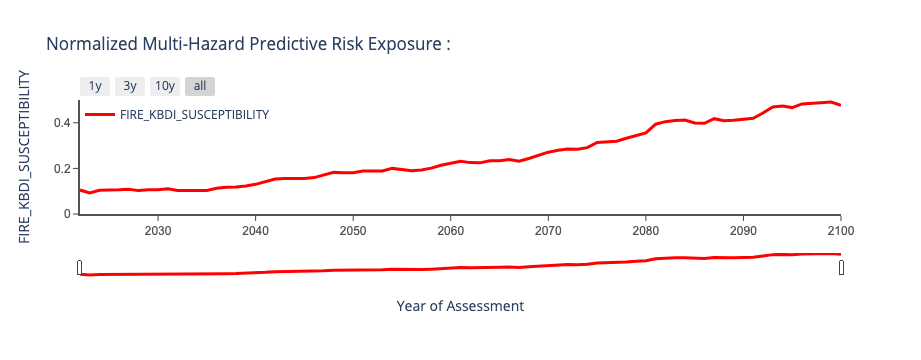

In [145]:
fig = display_fwd_timeseries_data(df, asset_index, 'FIRE_KBDI_SUSCEPTIBILITY')
fig.show()

In [146]:
# Fetch the risk exposure summary data, filtering to a specific
# scenario, hazard and summary window
pf = cl.portfolio(PORTFOLIO)
ds = pf.physical_risk_exposure()
sd = ds.summary(
    ds.scenarios.get('ssp585'),
    ds.hazards.get('water_stress'),
    ds.windows.get(30),
)

display(pd.DataFrame(sd.to_dicts()).sort_values(by=['risk_score'], ascending=False)[:5])

,risk_class,risk_score,hazard,portfolio_name,portfolio_index,entity_id,entity_name,window,window_start_year,scenario
57,HIGH,1.000000,water_stress,USNP_with_visits,10,,Christiansted National Historic Site,30,2022,ssp585
0,HIGH,0.857209,water_stress,USNP_with_visits,67,,Biscayne National Park,30,2022,ssp585
39,HIGH,0.857209,water_stress,USNP_with_visits,28,,Everglades National Park,30,2022,ssp585
86,HIGH,0.744806,water_stress,USNP_with_visits,87,,Cabrillo National Monument,30,2022,ssp585
42,HIGH,0.743481,water_stress,USNP_with_visits,25,,Kalaupapa National Historical Park,30,2022,ssp585


In [147]:
df['visitation_count'] = af['label:visitation_count'].values
df['lat'] = af['lat'].values
df['lng'] = af['lng'].values
idxmax = df['visitation_count'].idxmax()
display(df[idxmax:idxmax+1])

,portfolio_name,portfolio_index,entity_id,entity_name,hazard,indicator,scenario,measure,1980,1981,...,2094,2095,2096,2097,2098,2099,2100,visitation_count,lat,lng
16,USNP_with_visits,16,,Gateway Arch National Park,wildfire,fire_kbdi_susceptibility,ssp585,mid,0.012895,0.013082,...,0.019235,0.019486,0.019779,0.019765,0.019849,0.020082,0.020138,9060807,38.622573,-90.173442


# What does the risk profile for wildfire potential look like over US National Parks ?

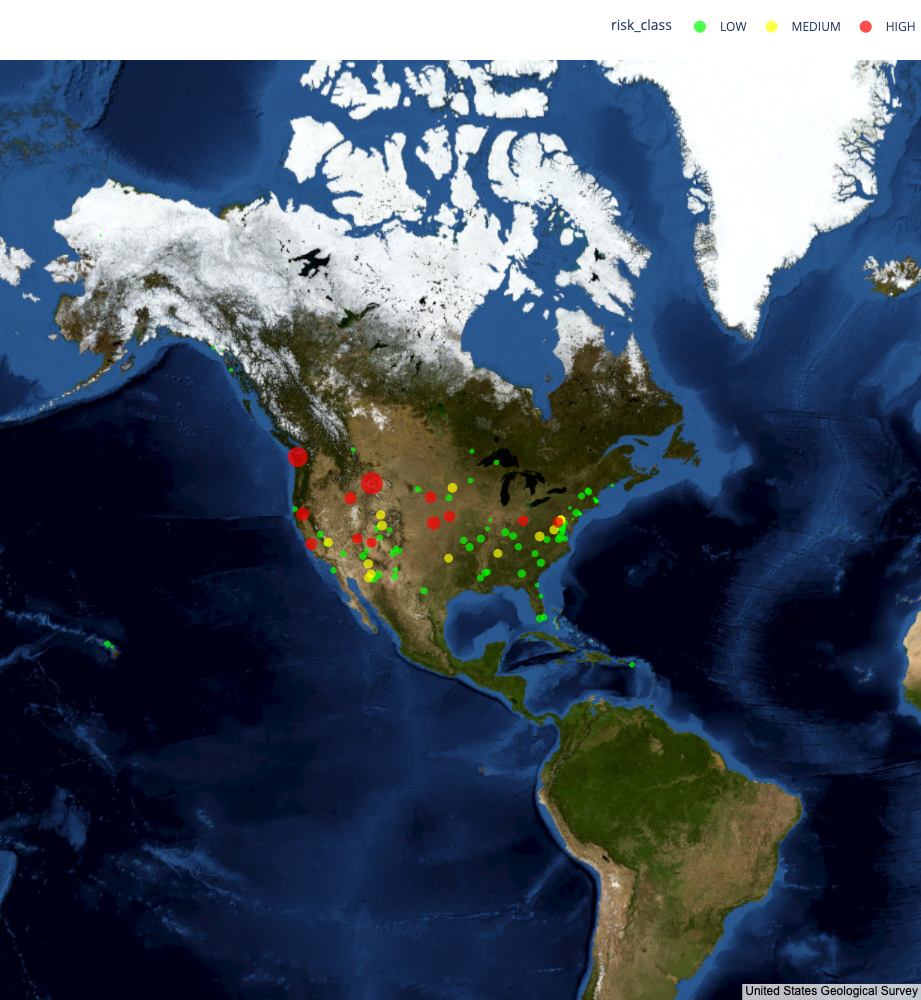

In [148]:
map_fig, df_risk = estimated_heatmap(df)
map_fig.show()

# Load up park visitation data

In [151]:
af = pd.read_csv('./data/USNPS_with_visits.csv')
display(af[:5])
df['visitation_count'] = af['label:visitation_count'].values

,entity_name,lng,lat,label:rank,label:visitation_count
0,Abraham Lincoln Birthplace National Historical...,-85.642493,37.612073,8,5792331
1,White House,-77.036556,38.896948,332,14205
2,Manzanar National Historic Site,-118.153032,36.726999,208,117113
3,Canaveral National Seashore,-80.747776,28.778219,37,2218059
4,Colorado National Monument,-108.689320,39.054719,118,499841


In [149]:
def estimate_visits_at_risk(df_risk):
    df_risk['visits_at_risk'] = df_risk.apply(lambda row: row.max_risk*row.visitation_count, axis=1)
    return df_risk

# Which parks are most likely to see visits affected by wildfire exposure ?

In [150]:
df_risk = estimate_visits_at_risk(df_risk)
presented_colnames = ['entity_name', 'max_risk', 'visitation_count', 'visits_at_risk']
display(df_risk[presented_colnames].sort_values(['visits_at_risk'], ascending=False).reset_index()[:5])

,index,entity_name,max_risk,visitation_count,visits_at_risk
0,44,Yellowstone National Park,0.336115,4860242,1.633599e+06
1,98,Olympic National Park,0.285262,2718925,7.756054e+05
2,86,Zion National Park,0.075873,5039835,3.823857e+05
3,35,Lincoln Boyhood National Memorial,0.049321,5792331,2.856826e+05
4,0,Abraham Lincoln Birthplace National Historical...,0.045119,5792331,2.613438e+05


In [15]:
pf_new = cl.create_portfolio('USNP_with_visits_again')
with open('./data/USNPS_with_visits.csv', 'rb') as af:
    pf_new.import_assets_csv(af)

In [11]:
pf_new1 = cl.create_portfolio('CMBS2')